# 🧮 Support Vector Machine (SVM) Classification

**🇹🇷 Türkçe:**
Bu notebook'ta **Destek Vektör Makineleri (SVM)** algoritmasını iki farklı veri seti üzerinde inceliyoruz. İlk bölümde kredi riski (loan risk) verisiyle **doğrusal (linear)** ve **RBF** çekirdeklerini karşılaştırıp `GridSearchCV` ile hiperparametre optimizasyonu yapıyoruz. İkinci bölümde ise doğrusal olarak ayrılamayan (non-linearly separable) bir sismik aktivite veri setiyle **kernel trick** fikrini elle (polinomsal öznitelikler türeterek) ve ardından RBF çekirdeğiyle gösteriyoruz.

**🇬🇧 English:**
This notebook explores the **Support Vector Machine (SVM)** algorithm on two datasets. In the first part, we compare **linear** and **RBF** kernels on a loan-risk dataset and tune hyperparameters with `GridSearchCV`. In the second part, we use a non-linearly separable seismic-activity dataset to illustrate the **kernel trick** — first manually, by engineering polynomial features, and then automatically, via the RBF kernel.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 1. Veri Setini Yükleme / Load the Dataset

**🇹🇷 Türkçe:**
İlk veri setimiz, kredi başvurusu yapan kişilerin kredi skoru dalgalanması ve son işlem hacmi bilgilerinden yola çıkarak kredi riskini (`loan_risk`) tahmin etmeyi amaçlıyor.

**🇬🇧 English:**
Our first dataset aims to predict loan risk (`loan_risk`) from a customer's credit score fluctuation and recent transaction volume.

In [2]:
df = pd.read_csv("../../Data/9-loan_risk_svm.csv")

In [3]:
df.head()

,credit_score_fluctuation,recent_transaction_volume,loan_risk
0,-1.439860,1.283010,1
1,-0.276571,-1.232382,0
2,1.312047,0.955097,1
3,1.020706,0.089485,0
4,1.513729,0.580520,1


In [4]:
df.describe()

,credit_score_fluctuation,recent_transaction_volume,loan_risk
count,1000.000000,1000.000000,1000.000000
mean,-0.024200,-0.018748,0.504000
std,1.257080,1.222329,0.500234
min,-3.562160,-2.641815,0.000000
25%,-1.001007,-0.995190,0.000000
50%,-0.105200,-0.142727,1.000000
75%,1.007451,0.964210,1.000000
max,2.984892,3.338639,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   credit_score_fluctuation   1000 non-null   float64
 1   recent_transaction_volume  1000 non-null   float64
 2   loan_risk                  1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


## ✂️ 2. Eğitim/Test Ayrımı / Train/Test Split

**🇹🇷 Türkçe:**
Hedef değişken (`loan_risk`) diğer özniteliklerden ayrılıyor ve veri, %80 eğitim / %20 test olacak şekilde bölünüyor.

**🇬🇧 English:**
The target variable (`loan_risk`) is separated from the features, and the data is split into 80% training / 20% test sets.

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X = df.drop('loan_risk', axis=1)
y = df['loan_risk']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 15)

## 🤖 3. Doğrusal (Linear) Çekirdek ile SVM / Linear Kernel SVM

**🇹🇷 Türkçe:**
SVM, sınıflar arasındaki **marjini (boşluğu)** en üst düzeye çıkaran bir ayırıcı hiper-düzlem (hyperplane) bulmaya çalışır. `kernel='linear'` ile veriyi doğrusal bir sınırla ayırmayı deniyoruz. `C` parametresi, yanlış sınıflandırmalara ne kadar tolerans gösterileceğini kontrol eder: küçük `C` daha geniş bir marj (daha fazla hata toleransı), büyük `C` ise daha dar bir marj (eğitim hatasına daha az tolerans) anlamına gelir.

**🇬🇧 English:**
SVM tries to find the separating hyperplane that **maximizes the margin** between classes. With `kernel='linear'`, we attempt to separate the data with a straight decision boundary. The `C` parameter controls the tolerance for misclassification: a small `C` allows a wider margin (more tolerance for errors), while a large `C` enforces a narrower margin (less tolerance for training errors).

In [9]:
from sklearn.svm import SVC

In [10]:
svm = SVC(kernel = 'linear', C = 1.0)

In [11]:
svm.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [12]:
from sklearn.metrics import classification_report, confusion_matrix

In [13]:
y_pred = svm.predict(X_test)

In [14]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[92  7]
 [ 9 92]]
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        99
           1       0.93      0.91      0.92       101

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



## 🌊 4. RBF Çekirdeği ile Karşılaştırma / RBF Kernel Comparison

**🇹🇷 Türkçe:**
Şimdi aynı veriyi `kernel='rbf'` (Radial Basis Function) ile deniyoruz. RBF çekirdeği, veriyi örtük olarak daha yüksek boyutlu bir uzaya taşıyarak doğrusal olmayan (non-linear) karar sınırları çizebilmemizi sağlar — bu fikre **"kernel trick"** denir.

**🇬🇧 English:**
Now we try the same data with `kernel='rbf'` (Radial Basis Function). The RBF kernel implicitly maps the data into a higher-dimensional space, allowing us to draw non-linear decision boundaries — this idea is called the **"kernel trick"**.

In [15]:
svm_rbf = SVC(kernel = 'rbf', C = 1.0)
svm_rbf.fit(X_train, y_train)
y_pred = svm_rbf.predict(X_test)
print(confusion_matrix(y_test, y_pred))

[[93  6]
 [10 91]]


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92        99
           1       0.94      0.90      0.92       101

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



## 🎛️ 5. GridSearchCV ile Hiperparametre Optimizasyonu / Hyperparameter Tuning with GridSearchCV

**🇹🇷 Türkçe:**
`C`, `kernel`, `degree` (polinom derecesi) ve `gamma` (RBF/poly çekirdeklerinin etki alanını belirler) parametrelerinin farklı kombinasyonlarını 5 katlamalı çapraz doğrulama (`cv=5`) ile tarayarak en iyi performansı veren kombinasyonu buluyoruz.

**🇬🇧 English:**
We search over combinations of `C`, `kernel`, `degree` (polynomial degree), and `gamma` (controls the reach of the RBF/poly kernels) using 5-fold cross-validation (`cv=5`) to find the best-performing combination.

In [17]:
model = SVC()

In [18]:
param_grid = {
    "C" : [0.1,1,10,100],
    "kernel" : ["linear","poly","rbf","sigmoid"],
    "degree" : [1,2,3,4,5,6],
    "gamma" : ["scale","auto"]
}

In [19]:
from sklearn.model_selection import GridSearchCV

In [20]:
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=5)

In [21]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'degree': [1, 2, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls 

In [22]:
grid.best_params_

{'C': 10, 'degree': 1, 'gamma': 'scale', 'kernel': 'rbf'}

In [23]:
y_pred_6 = grid.predict(X_test)

In [24]:
print(confusion_matrix(y_test, y_pred_6))
print(classification_report(y_test, y_pred_6))

[[93  6]
 [10 91]]
              precision    recall  f1-score   support

           0       0.90      0.94      0.92        99
           1       0.94      0.90      0.92       101

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



## 🌋 6. Bölüm 2: Sismik Aktivite Verisi — Doğrusal Ayrılamayan Bir Veri Seti / Part 2: Seismic Activity — A Non-Linearly Separable Dataset

**🇹🇷 Türkçe:**
İkinci veri setimiz, yer altı dalga enerjisi ve titreşim ekseni değişimine göre bir sismik olayın (`seismic_event_detected`) tespit edilip edilmediğini içeriyor. Bu veride sınıflar dairesel bir desenle iç içe geçmiş durumda — yani **doğrusal bir çizgiyle ayrılamıyor**. Bu, kernel trick fikrini göstermek için ideal bir örnek.

**🇬🇧 English:**
Our second dataset records whether a seismic event (`seismic_event_detected`) was detected, based on underground wave energy and vibration axis variation. In this data, the classes are arranged in a circular pattern — meaning they **cannot be separated by a straight line**. This makes it an ideal example for illustrating the kernel trick.

In [25]:
df2 = pd.read_csv("../../Data/9-seismic_activity_svm.csv")

In [26]:
df2.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [27]:
df2.describe()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
count,400.000000,4.000000e+02,400.000000
mean,0.000000,8.881784e-18,0.500000
std,7.719350,1.751650e+00,0.500626
min,-9.999954,-3.000000e+00,0.000000
25%,-6.134779,-1.500000e+00,0.000000
50%,0.000000,0.000000e+00,0.500000
75%,6.134779,1.500000e+00,1.000000
max,9.999954,3.000000e+00,1.000000


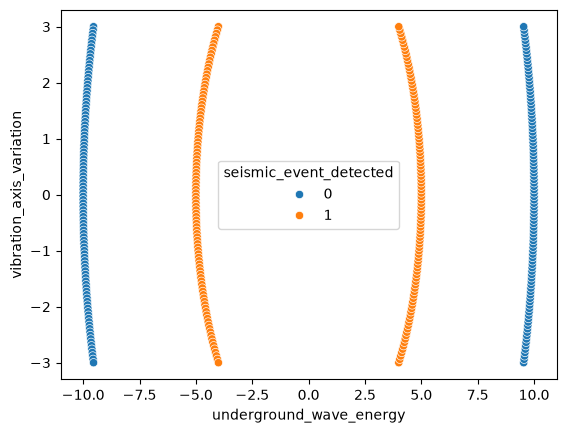

In [28]:
sns.scatterplot(x=df2["underground_wave_energy"], y=df2["vibration_axis_variation"], hue=df2["seismic_event_detected"])
plt.show()

### 🔧 Öznitelik Mühendisliği — Polinomsal Öznitelikler / Feature Engineering — Polynomial Features

**🇹🇷 Türkçe:**
Saçılım grafiğinde görüldüğü gibi sınıflar iç içe geçmiş dairesel bir desen oluşturuyor. Orijinal iki özniteliğin karelerini (`**2`) ve çarpımını elle türeterek veriyi, doğrusal bir sınırla ayrılabileceği yeni bir öznitelik uzayına taşıyoruz. Bu, RBF çekirdeğinin arka planda örtük olarak yaptığı işlemi gözle görülür şekilde göstermenin bir yolu.

**🇬🇧 English:**
As seen in the scatter plot, the classes form a nested circular pattern. By manually engineering the squares (`**2`) and product of the two original features, we transform the data into a new feature space where it becomes linearly separable. This makes visible, by hand, what the RBF kernel does implicitly under the hood.

> ⚠️ **Not:** Bu türetilmiş kolonlar yalnızca fikri **görselleştirmek** için üretiliyor; aşağıdaki son model onları kullanmayacak, doğrudan orijinal iki öznitelikle eğitilecek.

> ⚠️ **Note:** These engineered columns exist only to **visualize** the idea; the final model below does not use them and is trained directly on the two original features.


In [29]:
df2['underground_wave_energy **2']= df2['underground_wave_energy']**2
df2['vibration_axis_variation **2']= df2['vibration_axis_variation']**2
df2['underground_wave_energy*vibration_axis_variation'] = (df2['underground_wave_energy'] *df2['vibration_axis_variation'])
df2.head()


,underground_wave_energy,vibration_axis_variation,seismic_event_detected,underground_wave_energy **2,vibration_axis_variation **2,underground_wave_energy*vibration_axis_variation
0,9.539392,-3.000000,0,91.000000,9.000000,-28.618176
1,9.558241,-2.939394,0,91.359963,8.640037,-28.095434
2,9.576669,-2.878788,0,91.712580,8.287420,-27.569197
3,9.594678,-2.818182,0,92.057851,7.942149,-27.039548
4,9.612272,-2.757576,0,92.395776,7.604224,-26.506569


In [30]:
# Model SADECE orijinal iki oznitelikle egitilir; turetilen polinom kolonlari
# yalnizca yukaridaki 3B gorsellestirme icin uretilmisti.
# The model is trained on the ORIGINAL two features only; the engineered
# polynomial columns exist purely for the 3D visualization above.
X = df2[['underground_wave_energy', 'vibration_axis_variation']]
y = df2['seismic_event_detected']


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 15)

### 📊 Mühendislik Yapılmış Öznitelik Uzayının 3B Görselleştirmesi / 3D Visualization of the Engineered Feature Space

**🇹🇷 Türkçe:**
Yeni türetilen üç öznitelik (kareler ve çarpım) üç boyutlu bir uzayda çiziliyor. Bu görselleştirme, iki dairesel sınıfın yeni uzayda nasıl ayrılabilir hale geldiğini gösteriyor.

**🇬🇧 English:**
The three newly engineered features (the squares and the product) are plotted in 3D space. This visualization shows how the two circular classes become separable in the new feature space.

In [32]:
import plotly.express as px

In [33]:
fig = px.scatter_3d(df2, x='underground_wave_energy **2', y='vibration_axis_variation **2', z='underground_wave_energy*vibration_axis_variation',
              color='seismic_event_detected')
fig.show()

## 🚀 7. Son Model — RBF Çekirdekli SVM / Final Model — RBF Kernel SVM

**🇹🇷 Türkçe:**
Şimdi `kernel='rbf'` ile bir SVM modelini doğrudan orijinal (mühendislik yapılmamış) verilerle eğitiyoruz. RBF çekirdeği, elle yaptığımız polinomsal dönüşümü örtük olarak kendisi gerçekleştirdiği için manuel öznitelik mühendisliğine gerek kalmadan bu dairesel sınıfları başarıyla ayırabiliyor.

**🇬🇧 English:**
Now we train an SVM with `kernel='rbf'` directly on the original (non-engineered) data. Since the RBF kernel implicitly performs the same kind of polynomial transformation we did by hand, it can successfully separate these circular classes without any manual feature engineering.

In [34]:
model3 = SVC(kernel = "rbf", C = 1.0)
model3.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [35]:
y_pred_10 = model3.predict(X_test)

In [36]:
print(confusion_matrix(y_test, y_pred_10))
print(classification_report(y_test, y_pred_10))

[[32  0]
 [ 0 48]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        48

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



## ✅ Sonuç / Conclusion

**🇹🇷 Türkçe:**
Model, sismik veri setinde **%100 doğruluk** elde ediyor — bu da RBF çekirdeğinin, elle türettiğimiz polinomsal özniteliklerle çözdüğümüz aynı doğrusal olmayan sınıflandırma problemini otomatik olarak çözebildiğini doğruluyor. Bu notebook; doğrusal ve RBF çekirdeklerinin karşılaştırılmasını, `GridSearchCV` ile hiperparametre optimizasyonunu ve kernel trick fikrinin hem elle hem de otomatik olarak nasıl işlediğini bir arada gösteriyor.

**🇬🇧 English:**
The model achieves **100% accuracy** on the seismic dataset — confirming that the RBF kernel automatically solves the same non-linear classification problem we solved by hand with engineered polynomial features. This notebook ties together linear-vs-RBF kernel comparison, hyperparameter tuning with `GridSearchCV`, and a hands-on illustration of the kernel trick, both manual and automatic.